In [1]:
import utils
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import fisher_exact
from statsmodels.stats.multitest import multipletests
import seaborn as sns
from glob import glob
from collections import defaultdict, Counter
import community as community_louvain
from sklearn.metrics import pairwise_distances, jaccard_score
import networkx as nx
import requests

In [2]:
# read the extra nodes for each primary case
extra_nodes_primary = {}

for filepath in glob("../data/extra_nodes/*.txt"):
    key = os.path.splitext(os.path.basename(filepath))[0]
    with open(filepath) as f:
        extra_nodes_primary[key] = [line.strip() for line in f if line.strip()]

In [3]:
# filter the extra nodes so that we remain only with those thare are specific to each case
specific_primary = defaultdict(list)

for key, genes in extra_nodes_primary.items():
    down = set(utils.down_dict.get(key, []))
    up = set(utils.up_dict.get(key, []))
    mut = set(utils.mutation_t.get(key, []))
    allowed = down | up | mut
    specific_primary[key] = list(set(genes) & allowed)           

In [4]:
# make a dataframe with columns=genes and rows=cases, and assign 1 if the gene is in the sample and 0 otherwise
def make_dataframe(dictionary):
    
    all_genes = sorted({g for genes in dictionary.values() for g in genes})

    df = pd.DataFrame( 0,
                        index=dictionary.keys(),
                        columns=all_genes
                        )

    for sample, genes in dictionary.items():
        df.loc[sample, genes] = 1

    return df

df=make_dataframe(specific_primary)

In [5]:
# exclude the genes that are not found in almost any case or appear in almost all the cases
prev = df.mean(axis=0)
Xf = df.loc[:, (prev >= 0.03) & (prev <= 0.9)]

In [6]:
# to construct the networks of samples, we calculated the similarity between the cases, then we took the first most similar 5 neighbors
df_bool = Xf.astype(bool).values
D= pairwise_distances(df_bool, metric="jaccard")
S = 1 - D
np.fill_diagonal(S, 0)

k = 5
A = np.zeros_like(S)

for i in range(S.shape[0]):
    nn = np.argsort(S[i])[-k:]
    A[i, nn] = S[i, nn]

A = np.maximum(A, A.T)

nodes = list(Xf.index)  
n = len(nodes)

G = nx.Graph()
G.add_nodes_from(nodes)

for i in range(n):
    for j in range(i + 1, n):
        if A[i, j] > 0:
            G.add_edge(
                nodes[i],
                nodes[j],
                weight=A[i, j]
            )


print("Graph nodes:", G.number_of_nodes(), "edges:", G.number_of_edges())

Graph nodes: 134 edges: 592


In [7]:
# #we applied louvain, and we selected the conditions so that the modularity is the highest 
seeds = [0, 1, 2, 3, 4,5,6,7,8,9]

partitions = []
modularities = []

for s in seeds:
    
    partition = community_louvain.best_partition(G, resolution=0.95, weight="weight", random_state=s)
    modularity = community_louvain.modularity(partition, G)
    
    partitions.append(partition)
    modularities.append(modularity)
    
    n_clusters = len(set(partition.values()))
    
    print(f"Seed {s}: modularity={modularity:.3f}, clusters={n_clusters}")


Seed 0: modularity=0.468, clusters=4
Seed 1: modularity=0.468, clusters=4
Seed 2: modularity=0.466, clusters=4
Seed 3: modularity=0.469, clusters=4
Seed 4: modularity=0.473, clusters=4
Seed 5: modularity=0.470, clusters=4
Seed 6: modularity=0.445, clusters=4
Seed 7: modularity=0.468, clusters=4
Seed 8: modularity=0.476, clusters=4
Seed 9: modularity=0.467, clusters=4


In [8]:
# select the partition based on best modularity
best_idx = np.argmax(modularities)
best_partition = partitions[best_idx]
labels = np.array([best_partition[i] for i in best_partition])
print("Selected partition labels:", Counter(labels))

Selected partition labels: Counter({1: 36, 3: 36, 0: 33, 2: 29})


In [9]:
#where to save the figures
save_path = Path("../data/fig_comm")
save_path.mkdir(parents=True, exist_ok=True)

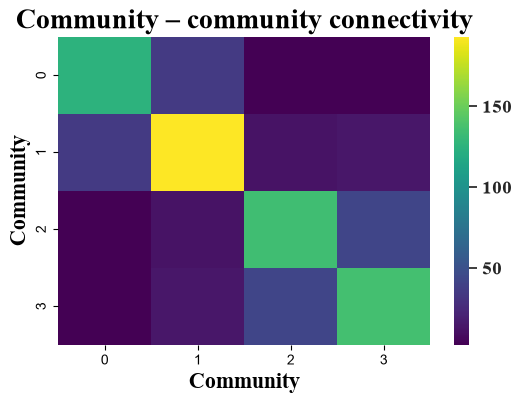

In [10]:
# plot the community-community connectivity to see how proeminent are they
fig, ax = plt.subplots(figsize=(6,4))
sns.set_theme(rc={'font.family': 'serif', 'font.serif': ['Times New Roman']})

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 16
plt.rcParams['font.weight'] = 'bold'

communities = sorted(set(best_partition.values()))
idx = {c: i for i, c in enumerate(communities)}
M = np.zeros((len(communities), len(communities)))

for u, v, data in G.edges(data=True):
    w = data.get("weight", 1.0)
    i, j = idx[best_partition[u]], idx[best_partition[v]]
    M[i, j] += w
    M[j, i] += w 

ax = sns.heatmap(M, cmap="viridis", cbar=True)
ax.collections[0].colorbar.ax.tick_params(labelsize=14)
plt.title("Community – community connectivity",fontsize=20, fontfamily='Times New Roman', fontweight='bold')
plt.xlabel("Community",fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.ylabel("Community",fontsize=16, fontfamily='Times New Roman', fontweight='bold')


plt.savefig(str(save_path)+"/comm.eps", dpi=500, bbox_inches='tight')
plt.show()

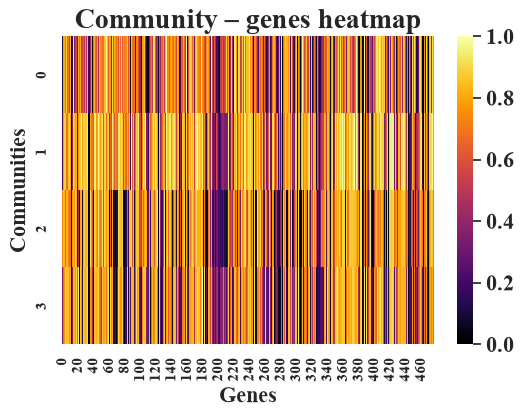

In [11]:
# plot the heatmap for the genes that were found in each community
communities = sorted(set(best_partition.values()))
idx = {c: i for i, c in enumerate(communities)}

C = np.zeros((len(communities), Xf.shape[1]))
counts = np.zeros(len(communities))

for node, c in best_partition.items():
    i = idx[c]
    C[i] += Xf.loc[node].values
    counts[i] += 1

C /= counts[:, None]
fig, ax = plt.subplots(figsize=(6,4))

sns.heatmap(C, cmap="inferno")#viridis,plasma,infermo,magma,cividis
ax.collections[0].colorbar.ax.tick_params(labelsize=16)
plt.xlabel("Genes", fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.ylabel("Communities", fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.title("Community – genes heatmap", fontsize=20, fontfamily='Times New Roman', fontweight='bold')

plt.savefig(str(save_path)+"/genes.eps", dpi=500, bbox_inches='tight')
plt.show()

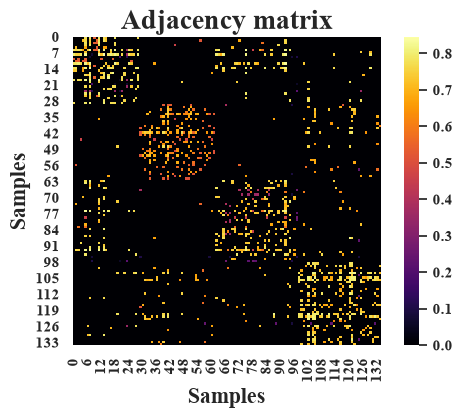

In [12]:
# plot the adjacency matrix to see how well separated the communities are
cluster_sizes = Counter(best_partition.values())

cluster_order = [2, 0,3,1]

nodes_sorted = sorted(
    G.nodes(),
    key=lambda n: cluster_order.index(best_partition[n])
)
#nodes_sorted = sorted(G.nodes(), key=lambda n: best_partition[n])
A = nx.to_numpy_array(G, nodelist=nodes_sorted)

fig, ax = plt.subplots(figsize=(6,4))
sns.heatmap(A, cmap="inferno", square=True)
plt.xlabel("Samples", fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.ylabel("Samples", fontsize=16, fontfamily='Times New Roman', fontweight='bold')
plt.title("Adjacency matrix", fontsize=20, fontfamily='Times New Roman', fontweight='bold')
plt.savefig(str(save_path)+"/adjacency.eps", dpi=500, bbox_inches='tight')
plt.show()

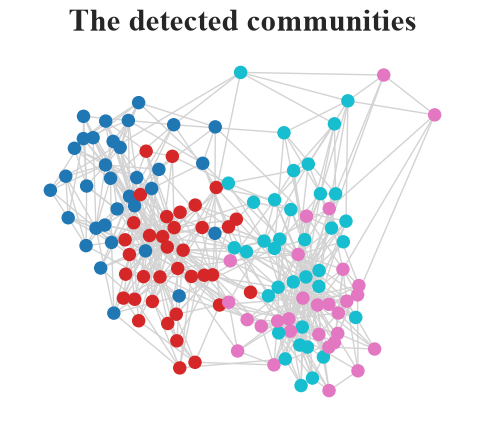

In [13]:
# plot the detected communities
pos = nx.spring_layout(G, seed=42)
colors = [best_partition[n] for n in G.nodes()]

fig, ax = plt.subplots(figsize=(6,5))
nx.draw(
    G, pos,
    node_color=colors,
    node_size=75,
    cmap=plt.cm.tab10,
    edge_color="lightgray",
    with_labels=False
)
plt.title("The detected communities", fontsize=22,fontfamily='Times New Roman', fontweight='bold')
plt.savefig(str(save_path)+"/detected.eps", dpi=500, bbox_inches='tight')
plt.show()

In [14]:
#save the obtained communities
Xf = Xf.copy()
Xf.loc[:, "community"] = Xf.index.map(best_partition)
Xf1=Xf["community"]
Xf1.to_excel("../data/obtained_communities.xlsx")

In [15]:
# calculate Fisher Exact Test, and the prevalences to be inside the community and outside the community

results = []
feature_cols = [
    c for c in Xf.columns
    if c not in ["community"]
]
for comm in Xf["community"].unique():
    in_comm = Xf[Xf["community"] == comm]
    out_comm = Xf[Xf["community"] != comm]

    for f in feature_cols:
        a = in_comm[f].sum()
        b = len(in_comm) - a
        c = out_comm[f].sum()
        d = len(out_comm) - c

        oddsratio, p = fisher_exact([[a, b], [c, d]], alternative="greater")

        results.append({
            "community": comm,
            "feature": f,
            "a_in": a,
            "c_out": c,
            "odds_ratio": oddsratio,
            "pvalue": p,
            "prevalence_in": a / len(in_comm),
            "prevalence_out": c / len(out_comm)
        })
res = pd.DataFrame(results)

# FDR correction per community
res["padj"] = (
    res.groupby("community")["pvalue"]
       .transform(lambda x: multipletests(x, method="fdr_bh")[1])
)


In [16]:
# filter to have only those with FDR < 0.05
res=res[res["padj"]<0.05]

In [17]:
#identify the markers that have the prevalence inside the community >= 0.7 and outside <=0.3 and save them
markers = res[(res["prevalence_in"] >= 0.7) & (res["prevalence_out"] <= 0.3)
          ].sort_values(["odds_ratio", "prevalence_in"], ascending=False
            )
res.to_excel("../data/fisher_gene.xlsx")
markers.to_excel("../data/fisher_gene_specific.xlsx")

In [18]:
markers

,community,feature,a_in,c_out,odds_ratio,pvalue,prevalence_in,prevalence_out,padj
1518,2,CHI3L1,25,15,37.500000,6.036943e-13,0.862069,0.142857,2.879622e-10
413,0,SOX11,29,19,31.289474,1.037963e-12,0.878788,0.188119,4.951086e-10
280,0,MNX1,26,13,25.142857,3.829764e-12,0.787879,0.128713,9.133987e-10
210,0,HOXD3,29,23,24.586957,2.635810e-11,0.878788,0.227723,4.190939e-09
1497,2,CD163,24,18,23.200000,8.696567e-11,0.827586,0.171429,2.074131e-08
593,1,DLGAP5,32,28,20.000000,2.203703e-10,0.888889,0.285714,6.219813e-08
186,0,HASPIN,29,28,18.901786,8.791909e-10,0.878788,0.277228,6.989568e-08
60,0,CBX2,27,20,18.225000,2.134773e-10,0.818182,0.198020,2.545717e-08
132,0,EME1,28,24,17.966667,5.041592e-10,0.848485,0.237624,4.809678e-08
753,1,MEOX2,29,20,16.157143,2.607888e-10,0.805556,0.204082,6.219813e-08


In [19]:
# group the genes by the communities to search on EnrichR
clusters_for_enrichR=(
                res.groupby("community")["feature"]
                    .apply(list)
                    .to_dict()
)


In [20]:
path_rez = "../data/pathways_clustering"
path_set = Path(path_rez)
path_set.mkdir(exist_ok=True)
os.chdir(path_rez)

for cluster in clusters_for_enrichR:
    utils.enrichent_results(clusters_for_enrichR[cluster], "cluster"+str(cluster), 'Reactome_Pathways_2024')

In [21]:
# make a dataframe with the results and filter them to have FDR < 0.05 
os.chdir("..")
folder = "./pathways_clustering"
files = glob(f"{folder}/*.txt")

df = pd.concat(
    [pd.read_csv(f, sep="\t").assign(filename=os.path.basename(f))
     for f in files],
    ignore_index=True
)

filtered_df = df[df["Adjusted P-value"] <0.05]

In [22]:
# exclude the pathways that are included in those obtained for common graph 

df_common= pd.read_csv("../data/graph_common_pathways_primary.txt", sep="\t")
df_common["filename"]="Common"
filtered_df_common=df_common[df_common["Adjusted P-value"] <0.05]
res_filtred_df = filtered_df[~filtered_df["Term"].isin(filtered_df_common["Term"])]
res_filtred_df.to_excel("Cluster_pathways_without_common.xlsx")

In [23]:
res_filtred_df

,Term,Overlap,P-value,Adjusted P-value,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,filename
11,Nucleosome Assembly,7/53,4.200181e-10,9.692726e-09,0,0,51.295505,1107.507048,H2BC9;CENPU;CENPH;CENPI;HJURP;CENPM;KNL1,cluster0.txt
12,Deposition of New CENPA-containing Nucleosomes...,7/53,4.200181e-10,9.692726e-09,0,0,51.295505,1107.507048,H2BC9;CENPU;CENPH;CENPI;HJURP;CENPM;KNL1,cluster0.txt
46,Specification of the Neural Plate Border,2/17,1.412725e-03,9.017392e-03,0,0,41.497917,272.319083,TFAP2A;GBX2,cluster0.txt
53,Assembly of the ORC Complex at the Origin of R...,2/37,6.630562e-03,3.616670e-02,0,0,17.766964,89.120261,H2BC9;ORC1,cluster0.txt
310,Nucleosome Assembly,7/53,2.355774e-09,5.339755e-08,0,0,39.268775,780.129044,CENPU;CENPI;CENPK;HJURP;CENPM;OIP5;KNL1,cluster1.txt
311,Deposition of New CENPA-containing Nucleosomes...,7/53,2.355774e-09,5.339755e-08,0,0,39.268775,780.129044,CENPU;CENPI;CENPK;HJURP;CENPM;OIP5;KNL1,cluster1.txt
336,Adenylate Cyclase Activating Pathway,2/10,7.673975e-04,5.592250e-03,0,0,60.695122,435.336102,GNAL;ADCY5,cluster1.txt
338,Presynaptic Depolarization and Calcium Channel...,2/12,1.119390e-03,7.611852e-03,0,0,48.551220,329.904145,CACNB4;CACNA1E,cluster1.txt
342,Adenylate Cyclase Inhibitory Pathway,2/14,1.535005e-03,9.709798e-03,0,0,40.455285,262.118758,GNAL;ADCY5,cluster1.txt
353,"Adrenaline,noradrenaline Inhibits Insulin Secr...",2/28,6.137828e-03,3.091647e-02,0,0,18.658537,95.033232,ADRA2C;ADCY5,cluster1.txt
